# Nearfield / layer rasterization

移植自 `tests/test_rasterization.py`：在与 `test_layer_visualizer.build_2d_shapes` 相同的 2D 图案上，
对比几种 layer raster API，并可视化结果。

- `raster_layer_binary_mask_s` / `_overlap_s` / `_thin_mask_s`
- `raster_layer_fourier_transform_s`（谱 → IFFT 到实空间再显示）
- `raster_layer_kottke_s`（ε 张量各分量的幅值/相位）

网格：`pitch=2.5`，`N=128`，`λ=1`，`NA=1`。


In [1]:
%matplotlib inline
import os
os.environ["SAVE_TO_FILE"] = "0"  # notebook 内嵌显示，不写 /tmp 图

import time
import numpy as np
import matplotlib.pyplot as plt

from simulation import *
import visualizer
from panel_renderer import render_frame
from viz_io import MODE_TITLES, component_array, save_or_show_fig
import viz_io as _viz_io
_viz_io.SAVE_TO_FILE = False

PITCH = 2.5
N = 128
WL = 1.0
NA = 1.0

KOTTKE_COMPS = (
    (0, "εxx"),
    (1, "εxy"),
    (2, "εyx"),
    (3, "εyy"),
    (4, "εzz"),
)


def _mat(name, eps):
    return share_material_s(material_s.from_epsilon(eps, name))


def build_2d_shapes():
    """与 tests/test_layer_visualizer.build_2d_shapes 一致。"""
    si, sio2, au, air, al, pr = (
        _mat("Si", 12 + 0j),
        _mat("SiO2", 2.1 + 0j),
        _mat("Au", -10 + 1.5j),
        _mat("Air", 1 + 0j),
        _mat("Al", -50 + 10j),
        _mat("PR", 2.5 + 0.01j),
    )
    grid = [(-0.75, 0.5), (0.0, 0.5), (0.75, 0.5), (-0.75, -0.5), (0.0, -0.5), (0.75, -0.5)]
    c0, c1, c2, c3, c4, c5 = grid
    p0, p1, p2 = [-0.16, -0.12], [0.18, -0.12], [0.02, 0.22]
    poly_verts = [
        [-0.22, -0.16], [0.22, -0.16], [0.22, 0.00],
        [0.00, 0.00], [0.00, 0.26], [-0.22, 0.26],
    ]
    return [
        make_circle_shape_s(0.20, list(c0), 0.0, si),
        make_ellipse_shape_s([0.26, 0.14], list(c1), 0.35, sio2),
        make_rect_shape_s([0.20, 0.12], list(c2), 0.0, au),
        make_poly_shape_s(poly_verts, list(c3), 0.0, al),
        make_bezier_poly_2_shape_s(
            [[p0, [0.01, -0.22], p1], [p1, [0.28, 0.08], p2], [p2, [-0.20, 0.10], p0]],
            list(c4), 0.0, pr,
        ),
        make_concentric_circles_shape_s([0.07, 0.16, 0.26], [si, air, au], list(c5), 0.0),
    ]


def make_layer_and_grid():
    shapes = build_2d_shapes()
    lyr = layer_s()
    lyr.background_material = share_material_s(material_s.from_epsilon(0 + 0j, "bg"))
    lyr.shapes = shapes
    lyr.parent = [-1] * len(shapes)
    grid = grid_info_2d_s.create_bloch_mode_fourier(
        [N, N], WL, 0.0, NA,
        [[-PITCH / 2, -PITCH / 2], [PITCH / 2, PITCH / 2]],
    )
    return lyr, grid


def as_cplx_field(raw):
    return np.asarray(raw, dtype=np.complex128).reshape((N, N))


def fourier_ifft(raw):
    """Corner-zero spectrum → spatial field（与 test / fourier_transform_mask 一致）。"""
    spec = np.asarray(raw, dtype=np.complex128).reshape((N, N))
    return (N * N) * np.fft.fftshift(np.fft.ifft2(spec))


def kottke_tensor(raw):
    """(N, N, 5) complex: exx, exy, eyx, eyy, ezz."""
    ncomp = len(KOTTKE_COMPS)
    out = np.empty((N, N, ncomp), dtype=np.complex128)
    for i, (idx, _) in enumerate(KOTTKE_COMPS):
        out[:, :, i] = np.asarray([t[idx] for t in raw], dtype=np.complex128).reshape((N, N))
    return out


def display_kottke_amp_phase(tensor, title):
    ncomp = len(KOTTKE_COMPS)
    assert tensor.shape == (N, N, ncomp)
    panels, titles, modes = [], [], []
    for i, (_, name) in enumerate(KOTTKE_COMPS):
        for mode in ("amp", "phase"):
            panels.append(component_array(tensor[:, :, i], mode))
            titles.append(f"{name} {MODE_TITLES[mode]}")
            modes.append(mode)
    fig = render_frame(
        panels, nrows=ncomp, ncols=2, titles=titles, panel_modes=modes,
        style="video", figure_title=title, figsize=(10, 2.2 * ncomp),
    )
    save_or_show_fig(fig, title=title)


lyr, grid = make_layer_and_grid()
print(f"shapes={len(lyr.shapes)}, grid N={N}, pitch={PITCH}")


shapes=6, grid N=128, pitch=2.5


## 几何预览

与 `test_layer_visualizer` 相同的 6 种 2D 形状（circle / ellipse / rect / L-poly / bezier / concentric）。


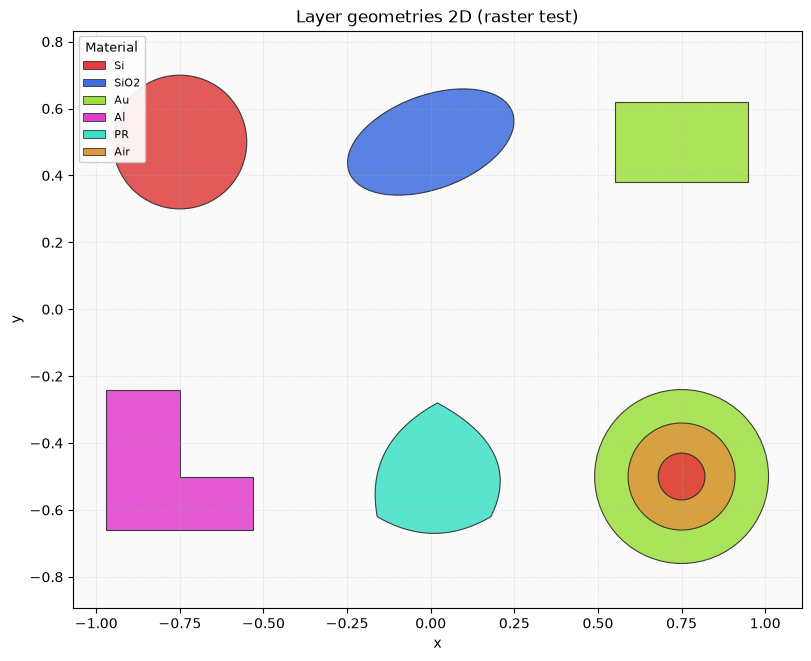

In [2]:
import layer_visualizer as lv
from viz_io import show_figure

# filmstack_visualizer: SAVE_TO_FILE=False 且 interactive=False 时会静默 close，需手动嵌入
ax = lv.plot_layer_geometries_2d(
    list(lyr.shapes), title="Layer geometries 2D (raster test)", show=False,
)
show_figure(ax.figure)


## Binary mask

`raster_layer_binary_mask_s`


[timing] raster_layer_binary_mask_s: 0.18 ms


[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)


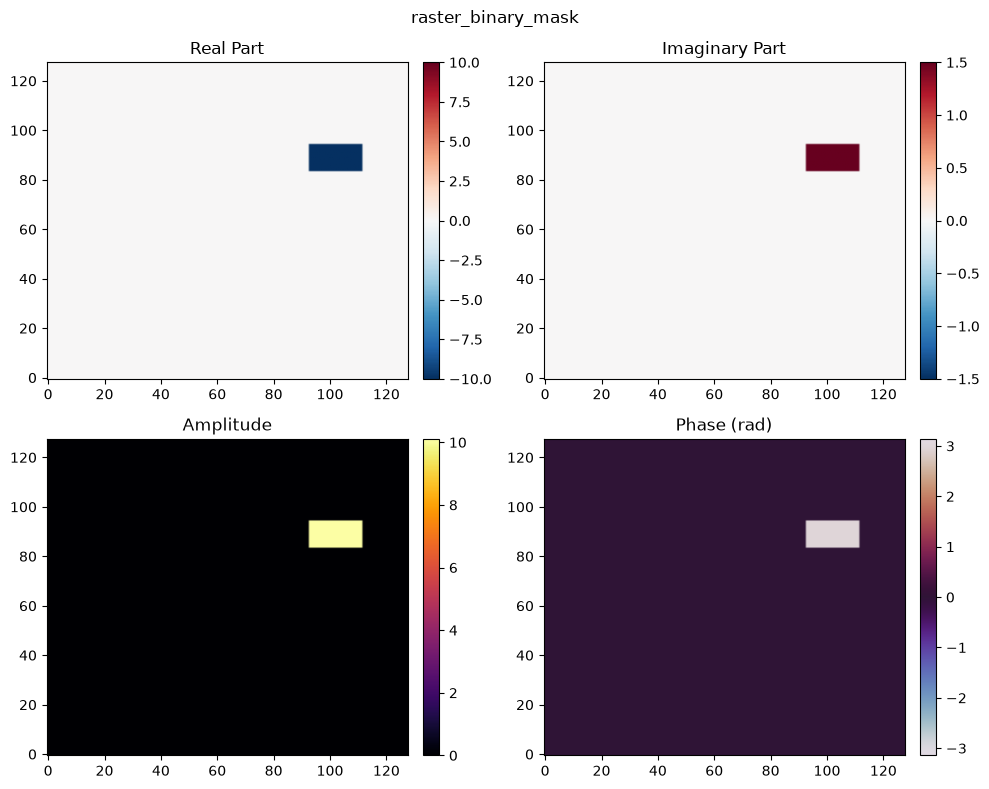

In [3]:
api = "raster_layer_binary_mask_s"
t0 = time.perf_counter()
raw = globals()[api](lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = as_cplx_field(raw)
assert field.shape == (N, N)
visualizer.display_complex_field(field, "raster_binary_mask")


## Binary mask (overlap)

`raster_layer_binary_mask_overlap_s`


[timing] raster_layer_binary_mask_overlap_s: 1.98 ms


[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)


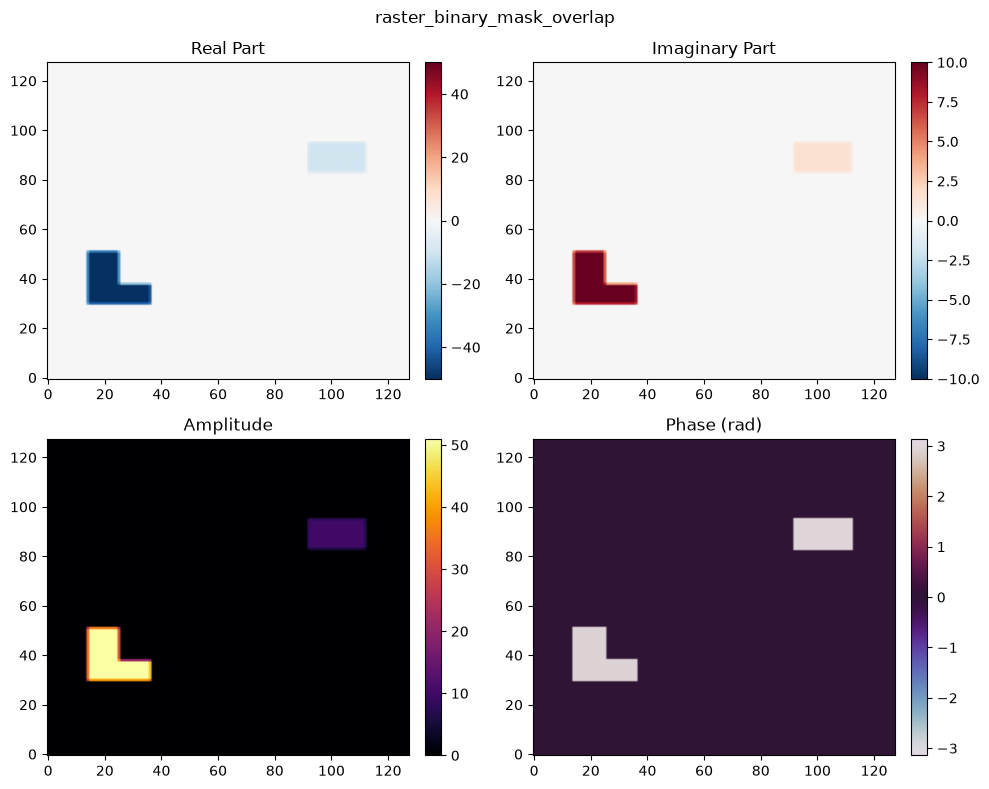

In [4]:
api = "raster_layer_binary_mask_overlap_s"
t0 = time.perf_counter()
raw = globals()[api](lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = as_cplx_field(raw)
assert field.shape == (N, N)
visualizer.display_complex_field(field, "raster_binary_mask_overlap")


## Thin mask

`raster_layer_thin_mask_s`（manhattan 友好的 rect / L-poly 会有非平凡结构）。


[timing] raster_layer_thin_mask_s: 3.51 ms


[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)
[Report]: binary_mask.hpp:113 poly2<real_t<T>> rasterization::detail::shape_to_poly_physical(const layer::layer_geometry_2d<T> &, bool) [T = float]. invalid arguments 1-th. (unsupported shape kind for spatial mask)


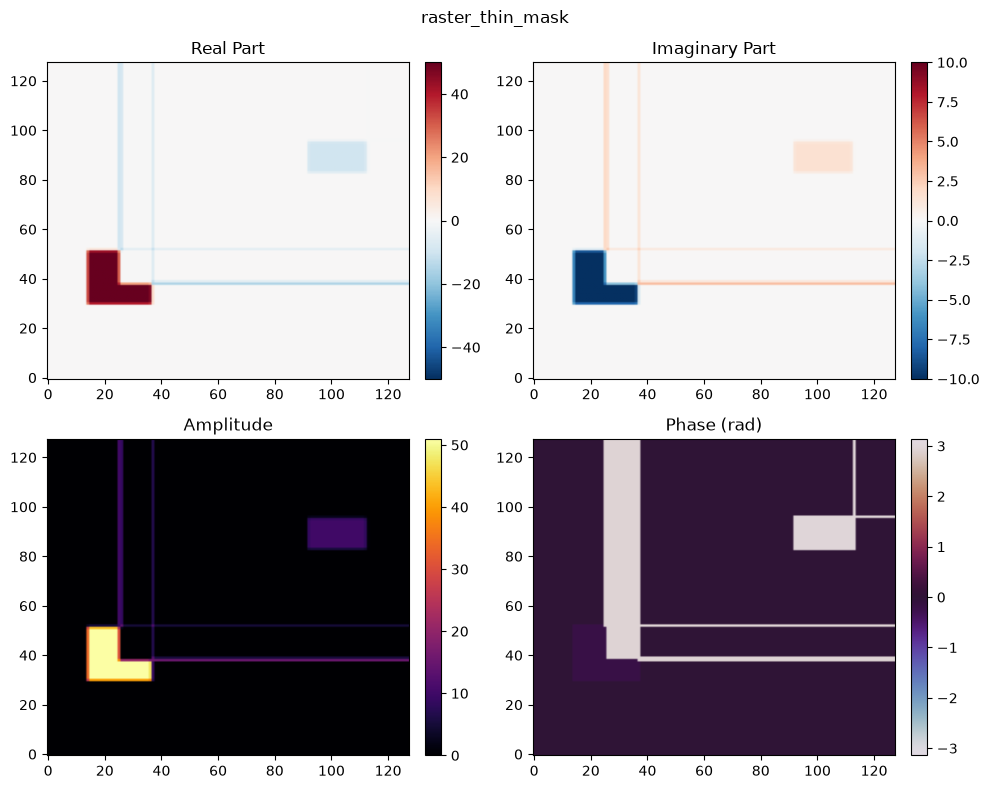

In [5]:
api = "raster_layer_thin_mask_s"
t0 = time.perf_counter()
raw = globals()[api](lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = as_cplx_field(raw)
assert field.shape == (N, N)
assert np.max(np.abs(field - field.flat[0])) > 1e-6
visualizer.display_complex_field(field, "raster_thin_mask")


## Fourier transform → IFFT

`raster_layer_fourier_transform_s` 得到 corner-zero 频谱，再 IFFT 到实空间显示（与测试一致）。


[timing] raster_layer_fourier_transform_s: 6129.90 ms


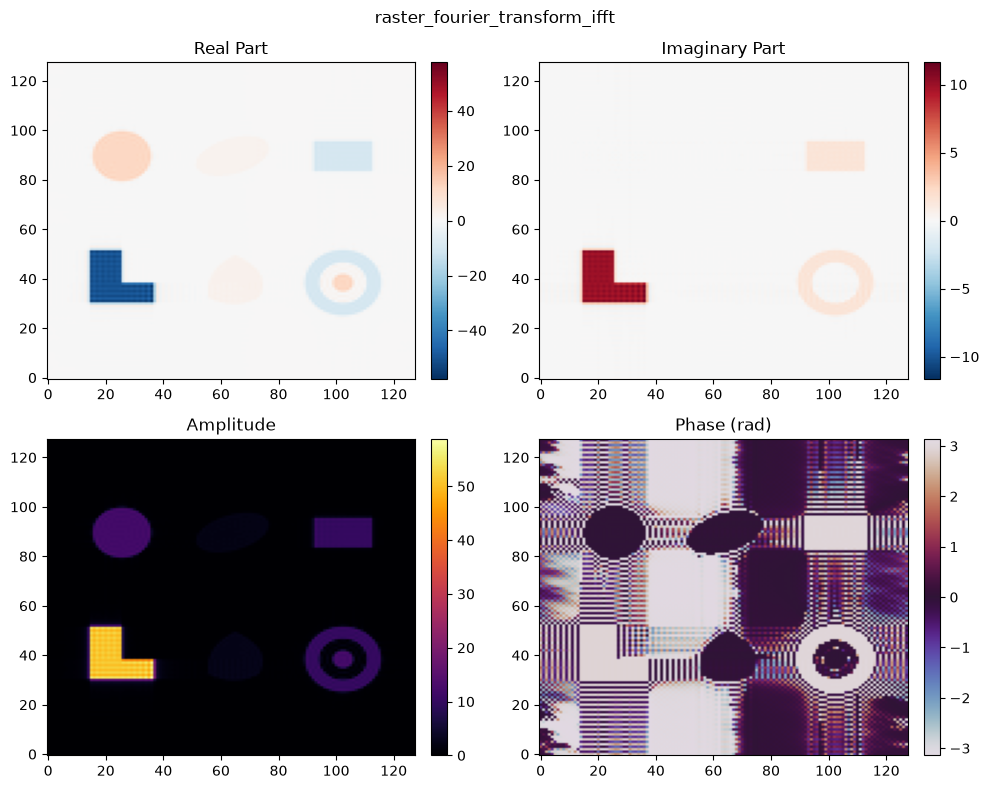

In [6]:
api = "raster_layer_fourier_transform_s"
t0 = time.perf_counter()
raw = globals()[api](lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = fourier_ifft(raw)
assert field.shape == (N, N)
visualizer.display_complex_field(field, "raster_fourier_transform_ifft")


## Kottke ε tensor

`raster_layer_kottke_s`：五个分量 εxx/εxy/εyx/εyy/εzz 的幅值与相位。


[timing] raster_layer_kottke_s: 4509.55 ms


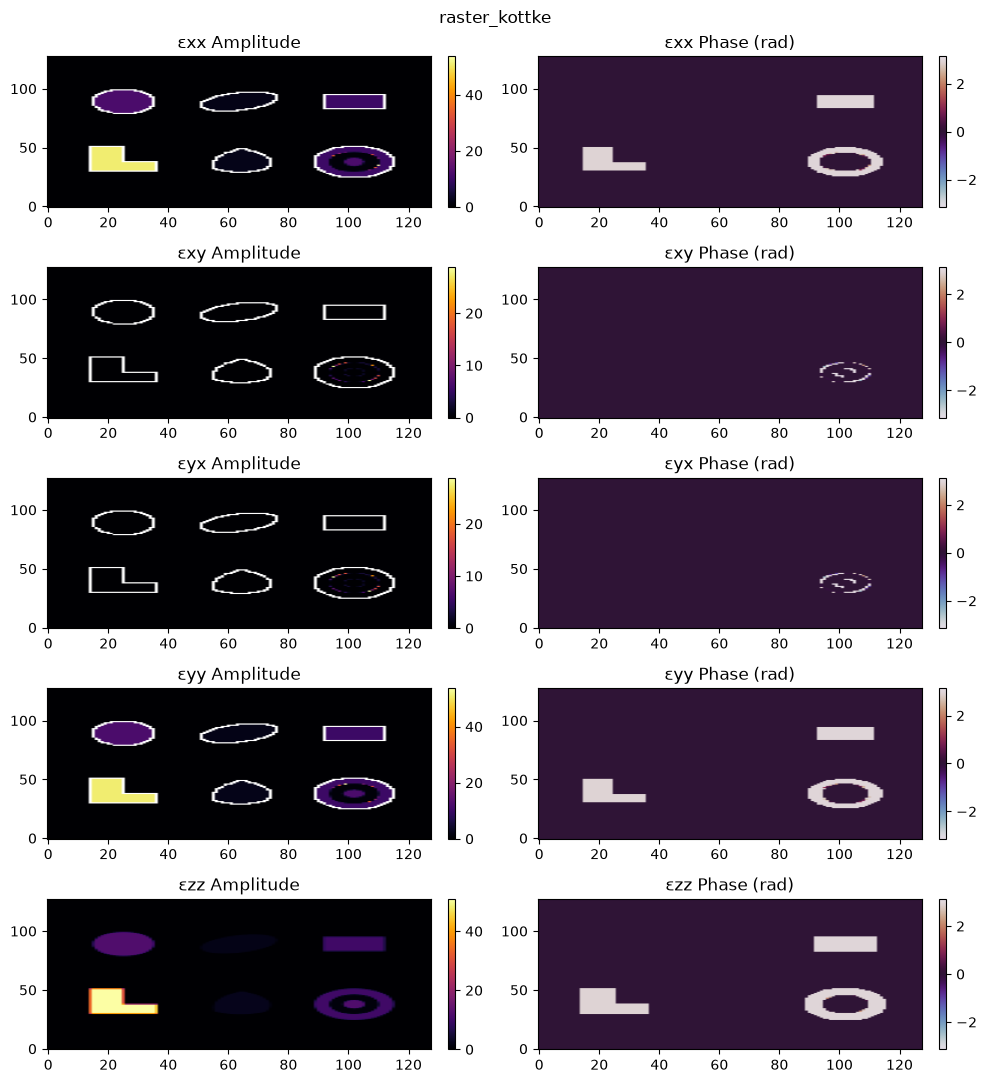

In [7]:
api = "raster_layer_kottke_s"
t0 = time.perf_counter()
raw = globals()[api](lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
assert len(raw) == N * N
tensor = kottke_tensor(raw)
assert tensor.shape == (N, N, len(KOTTKE_COMPS))
display_kottke_amp_phase(tensor, "raster_kottke")
